# SaaS Customer Support Swarm (Fully Interconnected Agent Network)

This notebook demonstrates a **fully interconnected agent swarm network** using pure LangChain (`create_agent`) subgraphs and LangGraph parent orchestration.

### Architectural Diagram:
Unlike a simple delegation tree or a rigid waterfall graph, this swarm model represents a **collaborative network** where any agent can transition to any other agent based on tool calls, and any agent can also choose to respond directly to the user.

```
                            ┌───────────────────┐
                            │    User Request   │
                            └─────────┬─────────┘
                                      │
                                      ▼
                            ┌───────────────────┐
                            │  Billing Agent  │◄─────────────────┐
                            └──────┬─────▲──────┘                  │
                      ┌────────────┘     └────────────┐            │
                      │ Handoff                       │ Handoff    │
                      ▼                               ▼            │
            ┌───────────────────┐           ┌───────────────────┐  │ Handoff
            │Tech Support Agent │◄─────────►│    Sales Agent    │──┘
            └───────────────────┘  Handoff  └───────────────────┘
```

### Swarm Agents:
1. **`BillingAgent`**: Handles invoicing, payment method updates, duplicate charges, and refunds.
2. **`TechSupportAgent`**: Runs diagnostics, resets API credentials, and troubleshoots rate limits.
3. **`SalesAgent`**: Manages subscription upgrades, downgrades, and customer retention discounts.

## 1. Setup & Environment Variables
Set up the API keys and initialize the chat model.

In [1]:
import os
from getpass import getpass
from dotenv import load_dotenv

# Load keys from root directory .env if present
load_dotenv(dotenv_path="../.env")

if "GEMINI_API_KEY" not in os.environ:
    if "GOOGLE_API_KEY" in os.environ:
        os.environ["GEMINI_API_KEY"] = os.environ["GOOGLE_API_KEY"]
    else:
        os.environ["GEMINI_API_KEY"] = getpass("Enter your GEMINI API Key: ")

## 2. Define Shared State Schema & Mock Databases
We'll define the shared customer database and the `SupportState` TypedDict for our agent swarm.

In [2]:
from typing import TypedDict, Annotated, Any
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

# Mock SaaS Customer Database
CUSTOMER_DB = {
    "alice@example.com": {
        "name": "Alice Smith",
        "plan_level": "Free",
        "account_status": "Active",
        "payment_method": "Visa-4111",
        "invoices": [{"id": "inv_001", "amount": 0.0, "status": "Paid"}]
    },
    "bob@example.com": {
        "name": "Bob Jones",
        "plan_level": "Pro",
        "account_status": "Active",
        "payment_method": "MasterCard-5555",
        "invoices": [
            {"id": "inv_002", "amount": 49.0, "status": "Paid"},
            {"id": "inv_003", "amount": 49.0, "status": "Paid"}  # duplicate transaction glitch
        ]
    },
    "charlie@example.com": {
        "name": "Charlie Brown",
        "plan_level": "Enterprise",
        "account_status": "Active",
        "payment_method": "Amex-3782",
        "invoices": [{"id": "inv_004", "amount": 299.0, "status": "Paid"}]
    }
}

class SupportState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    active_agent: str
    customer_email: str
    customer_info: dict       # name, plan_level, account_status
    billing_status: dict      # payment_method, invoices, pending_refunds
    diagnostic_log: dict      # last_error, resolved_status

## 3. Implement Swarm Handoff & Action Tools
We'll define specialized business tools and bidirectional handoff tools returning `Command(goto=..., graph=Command.PARENT)` to coordinate transitions.

In [4]:
from langchain_core.tools import tool, InjectedToolCallId
from langgraph.prebuilt import InjectedState
from langgraph.types import Command
from langchain_core.messages import AIMessage, ToolMessage

# --- 1. Billing Agent Tools ---
@tool("process_refund")
def process_refund(
    email: str,
    invoice_id: str
) -> str:
    """Process a refund for a given customer invoice ID."""
    cust = CUSTOMER_DB.get(email)
    if not cust:
        return f"Error: Customer with email '{email}' not found."
    
    invoices = cust.get("invoices", [])
    invoice = next((inv for inv in invoices if inv["id"] == invoice_id), None)
    if not invoice:
        return f"Error: Invoice '{invoice_id}' not found for customer '{email}'."
    
    if invoice["status"] == "Refunded":
        return f"Invoice '{invoice_id}' has already been refunded."
        
    invoice["status"] = "Refunded"
    return f"Success: Refund processed successfully for invoice '{invoice_id}' (Amount: ${invoice['amount']})."

@tool("update_payment_method")
def update_payment_method(
    email: str,
    new_method: str
) -> str:
    """Update the customer's payment method (e.g. Visa-1111)."""
    cust = CUSTOMER_DB.get(email)
    if not cust:
        return f"Error: Customer with email '{email}' not found."
    cust["payment_method"] = new_method
    return f"Success: Updated payment method to '{new_method}' for '{email}'."

@tool("transfer_billing_to_tech_support")
def transfer_billing_to_tech_support(
    reason: str,
    tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """Transfer control to Technical Support when the billing query involves software bugs or diagnostics."""
    return Command(
        goto="tech_support",
        graph=Command.PARENT,
        update={
            "active_agent": "tech_support",
            "messages": [
                ToolMessage(content="Transferred to Tech Support.", tool_call_id=tool_call_id),
                AIMessage(content=f"[System Handoff]: Billing is transferring you to Technical Support: {reason}")
            ]
        }
    )

@tool("transfer_billing_to_sales")
def transfer_billing_to_sales(
    reason: str,
    tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """Transfer control to Sales when the customer asks about upgrades, plan pricing, or retention options."""
    return Command(
        goto="sales",
        graph=Command.PARENT,
        update={
            "active_agent": "sales",
            "messages": [
                ToolMessage(content="Transferred to Sales.", tool_call_id=tool_call_id),
                AIMessage(content=f"[System Handoff]: Billing is transferring you to Sales: {reason}")
            ]
        }
    )

# --- 2. Tech Support Agent Tools ---
@tool("run_diagnostics")
def run_diagnostics(
    email: str
) -> str:
    """Run diagnostics on the customer's account to identify API rate limit errors or system glitches."""
    cust = CUSTOMER_DB.get(email)
    if not cust:
        return f"Error: Customer '{email}' not found."
    
    if email == "alice@example.com":
        return "Diagnostic Output: Account is active. Error: API_RATE_LIMIT_EXCEEDED (User is on Free tier)."
    elif email == "bob@example.com":
        return "Diagnostic Output: Account is active. Error: SYSTEM_GLITCH_DUPLICATE_WEBHOOK (Duplicate charge triggered on invoice inv_003). Status: Resolved."
    else:
        return "Diagnostic Output: Account is healthy. No issues detected."

@tool("reset_api_key")
def reset_api_key(
    email: str
) -> str:
    """Reset the API credential key for the customer."""
    cust = CUSTOMER_DB.get(email)
    if not cust:
        return f"Error: Customer '{email}' not found."
    return f"Success: API key successfully reset for '{email}'. A new token has been generated."

@tool("transfer_tech_to_billing")
def transfer_tech_to_billing(
    reason: str,
    tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """Transfer control to Billing when the issue is resolved and requires refunds, invoices, or charges."""
    return Command(
        goto="billing",
        graph=Command.PARENT,
        update={
            "active_agent": "billing",
            "messages": [
                ToolMessage(content="Transferred to Billing.", tool_call_id=tool_call_id),
                AIMessage(content=f"[System Handoff]: Technical Support is transferring you back to Billing: {reason}")
            ]
        }
    )

@tool("transfer_tech_to_sales")
def transfer_tech_to_sales(
    reason: str,
    tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """Transfer control to Sales when the user hits a plan limit or needs to upgrade/buy extra capacity."""
    return Command(
        goto="sales",
        graph=Command.PARENT,
        update={
            "active_agent": "sales",
            "messages": [
                ToolMessage(content="Transferred to Sales.", tool_call_id=tool_call_id),
                AIMessage(content=f"[System Handoff]: Technical Support is transferring you to Sales: {reason}")
            ]
        }
    )

# --- 3. Sales Agent Tools ---
@tool("upgrade_subscription")
def upgrade_subscription(
    email: str,
    new_plan: str
) -> str:
    """Upgrade the customer's plan level (e.g. Pro, Enterprise)."""
    cust = CUSTOMER_DB.get(email)
    if not cust:
        return f"Error: Customer '{email}' not found."
    old_plan = cust["plan_level"]
    cust["plan_level"] = new_plan
    return f"Success: Upgraded plan level from '{old_plan}' to '{new_plan}' for '{email}'."

@tool("apply_discount")
def apply_discount(
    email: str,
    discount_percent: float
) -> str:
    """Apply a percentage discount on future invoices for the customer (retention)."""
    cust = CUSTOMER_DB.get(email)
    if not cust:
        return f"Error: Customer '{email}' not found."
    return f"Success: Applied a {discount_percent}% loyalty discount on future billing for '{email}'."

@tool("transfer_sales_to_billing")
def transfer_sales_to_billing(
    reason: str,
    tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """Transfer control to Billing to process credit card details, invoices, or billing setups."""
    return Command(
        goto="billing",
        graph=Command.PARENT,
        update={
            "active_agent": "billing",
            "messages": [
                ToolMessage(content="Transferred to Billing.", tool_call_id=tool_call_id),
                AIMessage(content=f"[System Handoff]: Sales is transferring you to Billing: {reason}")
            ]
        }
    )

@tool("transfer_sales_to_tech_support")
def transfer_sales_to_tech_support(
    reason: str,
    tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """Transfer control to Technical Support when the customer needs a deep technical evaluation or integration advice."""
    return Command(
        goto="tech_support",
        graph=Command.PARENT,
        update={
            "active_agent": "tech_support",
            "messages": [
                ToolMessage(content="Transferred to Tech Support.", tool_call_id=tool_call_id),
                AIMessage(content=f"[System Handoff]: Sales is transferring you to Technical Support: {reason}")
            ]
        }
    )


## 4. Instantiate Swarm Sub-Agents using `create_agent`
We'll define system prompts instructing each agent on when to run business actions and when to route to its peers.

In [5]:
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)

# 1. Billing Agent
billing_agent = create_agent(
    model=llm,
    tools=[process_refund, update_payment_method, transfer_billing_to_tech_support, transfer_billing_to_sales],
    system_prompt=(
        "You are a Billing Agent. You process refunds, update payment methods, and resolve disputes. "
        "- If a customer requests a refund because of a system glitch or webhook error, first run diagnostics. If you cannot diagnose it, "
        "  transfer to Technical Support using transfer_billing_to_tech_support to let them inspect and resolve the error. "
        "- If the customer is complaining about pricing, wants to cancel, or wants to upgrade, transfer to Sales using transfer_billing_to_sales."
    ),
    state_schema=SupportState,
    name="billing"
)

# 2. Tech Support Agent
tech_support_agent = create_agent(
    model=llm,
    tools=[run_diagnostics, reset_api_key, transfer_tech_to_billing, transfer_tech_to_sales],
    system_prompt=(
        "You are a Technical Support Agent. You diagnose errors, run system checks, and reset keys. "
        "- Run diagnostics using run_diagnostics to see what's wrong with the customer's account. "
        "- If you diagnose that a user is hitting limits because they are on a Free plan, transfer to Sales using transfer_tech_to_sales to offer an upgrade. "
        "- If you diagnose a payment duplicate webhook bug and resolve it, transfer to Billing using transfer_tech_to_billing so they can process the refund."
    ),
    state_schema=SupportState,
    name="tech_support"
)

# 3. Sales Agent
sales_agent = create_agent(
    model=llm,
    tools=[upgrade_subscription, apply_discount, transfer_sales_to_billing, transfer_sales_to_tech_support],
    system_prompt=(
        "You are a Sales Agent. You upgrade subscriptions and apply loyalty discounts for customer retention. "
        "- If a customer agrees to upgrade their plan, call upgrade_subscription, and then transfer to Billing using transfer_sales_to_billing to update invoice payments. "
        "- If a customer asks deep integration questions or technical setup problems, transfer to Technical Support using transfer_sales_to_tech_support."
    ),
    state_schema=SupportState,
    name="sales"
)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


## 5. Construct Parent Graph Orchestrator
We'll assemble the parent StateGraph and configure dynamic routing to start each conversation turn with the active agent.

In [6]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

builder = StateGraph(SupportState)

# Add agent nodes
builder.add_node("billing", billing_agent)
builder.add_node("tech_support", tech_support_agent)
builder.add_node("sales", sales_agent)

# Route from START node based on active_agent state
def route_active_agent(state: SupportState):
    return state.get("active_agent", "billing")

builder.add_conditional_edges(
    START,
    route_active_agent,
    ["billing", "tech_support", "sales"]
)

# Define fully interconnected Swarm routing edges to allow visualization arrows
def route_billing(state: SupportState):
    return "end"
builder.add_conditional_edges(
    "billing",
    route_billing,
    {"tech_support": "tech_support", "sales": "sales", "end": END}
)

def route_tech(state: SupportState):
    return "end"
builder.add_conditional_edges(
    "tech_support",
    route_tech,
    {"billing": "billing", "sales": "sales", "end": END}
)

def route_sales(state: SupportState):
    return "end"
builder.add_conditional_edges(
    "sales",
    route_sales,
    {"billing": "billing", "tech_support": "tech_support", "end": END}
)

# Database and compilation
import os
if os.path.exists("support_checkpoints.db"):
    try:
        os.remove("support_checkpoints.db")
    except Exception:
        pass

conn = sqlite3.connect("support_checkpoints.db", check_same_thread=False)
memory = SqliteSaver(conn)
support_swarm = builder.compile(checkpointer=memory)
print("Support Swarm Network Graph successfully compiled!")

Support Swarm Network Graph successfully compiled!


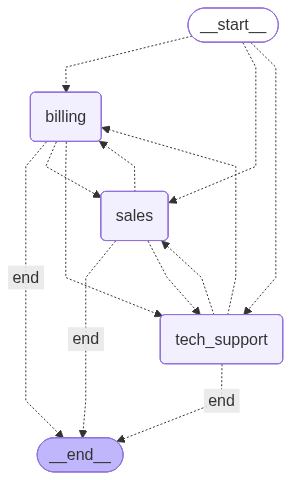

In [7]:
support_swarm

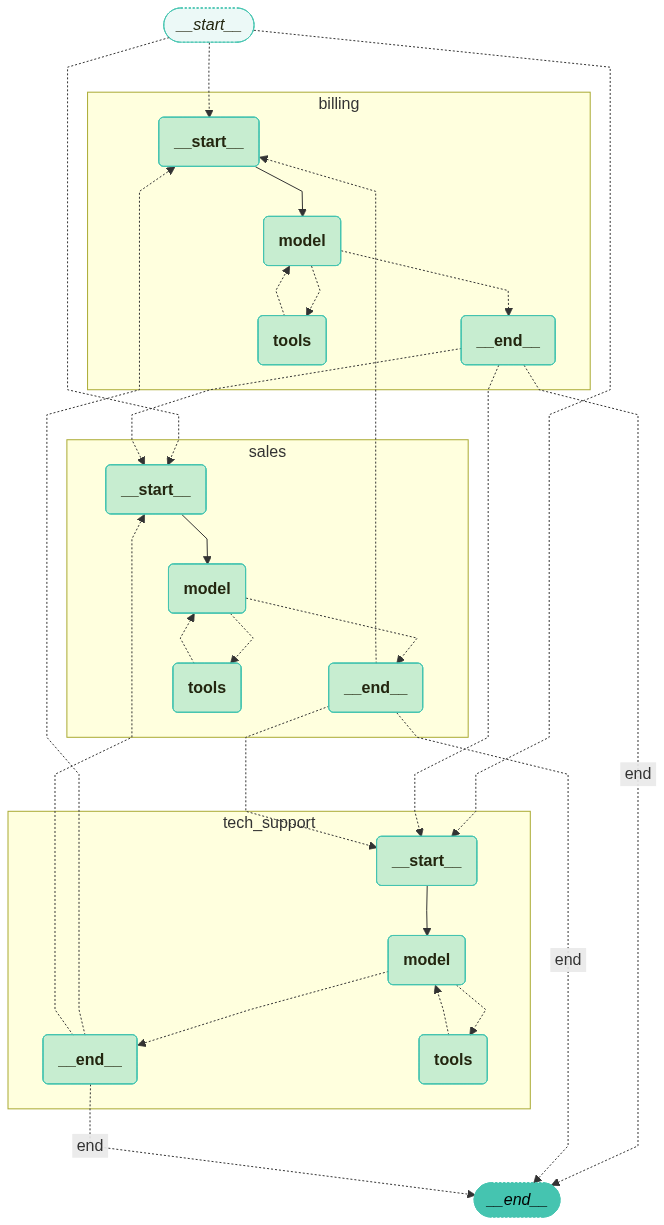

In [8]:
from langchain_opentutorial.graphs import visualize_graph
visualize_graph(support_swarm, xray=True)

## 6. Demonstration Scenarios
We'll simulate the three multi-turn, cross-agent support flows.

### Scenario 1: Tech issue resolves to a plan upgrade
Applicant: **Alice Smith** (`alice@example.com`).
Workflow: `TechSupport` (diagnostic limit check) $\rightarrow$ `Sales` (upgrade plan) $\rightarrow$ `Billing` (process payment).

In [9]:
config_1 = {"configurable": {"thread_id": "thread_scenario_1"}}

# Turn 1: User queries Tech Support about errors
msg_alice_1 = "Hello, I am getting errors on my account. My email is alice@example.com. Can you check what is wrong?"
print(f"User Message: {msg_alice_1}\n")
res = support_swarm.invoke(
    {"messages": [("user", msg_alice_1)], "active_agent": "tech_support"},
    config=config_1
)
print("\n--- Alice Turn 1 Output ---")
print(res["messages"][-1].content)
print(f"Active Agent: {res['active_agent']}\n")



User Message: Hello, I am getting errors on my account. My email is alice@example.com. Can you check what is wrong?


--- Alice Turn 1 Output ---
[{'type': 'text', 'text': "\n\nI'm sorry to hear you're having trouble with your account, Alice. It looks like you're hitting some API rate limits because you're currently on our Free tier. \n\nTo resolve this and get better performance, I recommend upgrading to our Pro plan. Would you like me to go ahead and upgrade your account for you?"}]
Active Agent: sales



In [10]:
# Turn 2: User agrees to upgrade subscription
msg_alice_2 = "Yes, please upgrade my subscription to the Pro plan."
print(f"User Message: {msg_alice_2}\n")
res = support_swarm.invoke(
    {"messages": [("user", msg_alice_2)]},
    config=config_1
)
print("\n--- Alice Turn 2 Output ---")
print(res["messages"][-1].content)
print(f"Active Agent: {res['active_agent']}\n")



User Message: Yes, please upgrade my subscription to the Pro plan.


--- Alice Turn 2 Output ---
[{'type': 'text', 'text': "\n\nI'd be happy to help you with that upgrade, Alice. To proceed with the Pro plan, I'll need to update your payment method. Could you please provide the new payment method details you'd like to use?"}]
Active Agent: billing



In [11]:
# Turn 3: User confirms payment details
msg_alice_3 = "Great, please confirm the charge on my Visa card on file."
print(f"User Message: {msg_alice_3}\n")
res = support_swarm.invoke(
    {"messages": [("user", msg_alice_3)]},
    config=config_1
)
print("\n--- Alice Turn 3 Output ---")
print(res["messages"][-1].content)
print(f"Active Agent: {res['active_agent']}")

User Message: Great, please confirm the charge on my Visa card on file.


--- Alice Turn 3 Output ---
[{'type': 'text', 'text': 'OK, Alice. I have successfully updated your payment method to your Visa card on file. Your account has been upgraded to the Pro plan. Is there anything else I can assist you with today?', 'extras': {'signature': 'EjQKMgEMOdbH0f1PvdQ49DcAFluiK6K41ACuFOkbHQpUiSr9kPFJTjwqI89Ye6AWokesk3we'}}]
Active Agent: billing


In [12]:
res

{'messages': [HumanMessage(content='Hello, I am getting errors on my account. My email is alice@example.com. Can you check what is wrong?', additional_kwargs={}, response_metadata={}, id='dc0df0b3-1d26-4d42-92bb-d555137b730a'),
  ToolMessage(content='Transferred to Sales.', name='transfer_tech_to_sales', id='606ea80c-9cc3-4187-8b77-5bbd80a28ac1', tool_call_id='2e9c18ff-8f06-4289-b2cf-3b0175673962'),
  AIMessage(content='[System Handoff]: Technical Support is transferring you to Sales: The user is hitting API rate limits because they are on the Free tier and need to upgrade their plan.', additional_kwargs={}, response_metadata={}, id='21948b7d-4a7a-4381-b965-0becd3c353d0', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content=[{'type': 'text', 'text': "\n\nI'm sorry to hear you're having trouble with your account, Alice. It looks like you're hitting some API rate limits because you're currently on our Free tier. \n\nTo resolve this and get better performance, I recommend upgrading 

### Scenario 2: Billing dispute caused by a tech bug
Applicant: **Bob Jones** (`bob@example.com`).
Workflow: `Billing` $\rightarrow$ `TechSupport` (diagnose glitch) $\rightarrow$ `Billing` (refund charge).

In [13]:
config_2 = {"configurable": {"thread_id": "thread_scenario_2"}}

# Turn 1: User contacts billing for refund
msg_bob_1 = "Hi, my email is bob@example.com. I notice I was charged twice ($49.00 each) on my statement for last month. Can you refund one of them?"
print(f"User Message: {msg_bob_1}\n")
res = support_swarm.invoke(
    {"messages": [("user", msg_bob_1)], "active_agent": "billing"},
    config=config_2
)
print("\n--- Bob Turn 1 Output ---")
print(res["messages"][-1].content)
print(f"Active Agent: {res['active_agent']}\n")



User Message: Hi, my email is bob@example.com. I notice I was charged twice ($49.00 each) on my statement for last month. Can you refund one of them?


--- Bob Turn 1 Output ---
[{'type': 'text', 'text': "I'm sorry to hear about the double charge. I attempted to process a refund for your last month's invoice, but I couldn't locate an invoice with that description.\n\nCould you please provide the specific invoice ID for the duplicate charge? You can usually find this on your billing statement or in the email receipt you received. Once I have that, I'll be happy to process the refund for you.", 'extras': {'signature': 'EjQKMgEMOdbHv+PS4oqUIGUj4pyC7aHKmh32o6iYaRkQeguHwGOvtinpi4lrB+my+iKye4qu'}}]
Active Agent: billing



In [14]:
#  # Turn 2: User agrees to system analysis
# msg_bob_2 = "Sure, please inspect the duplicate charge error."
# print(f"User Message: {msg_bob_2}\n")
# res = support_swarm.invoke(
#     {"messages": [("user", msg_bob_2)]},
#     config=config_2
# )
# print("\n--- Bob Turn 2 Output ---")
# print(res["messages"][-1].content)
# print(f"Active Agent: {res['active_agent']}\n")

# Turn 3: User asks billing to complete refund
msg_bob_3 = "Excellent, please refund invoice inv_003."
print(f"User Message: {msg_bob_3}\n")
res = support_swarm.invoke(
    {"messages": [("user", msg_bob_3)]},
    config=config_2
)
print("\n--- Bob Turn 3 Output ---")
print(res["messages"][-1].content)
print(f"Active Agent: {res['active_agent']}")

User Message: Excellent, please refund invoice inv_003.


--- Bob Turn 3 Output ---
[{'type': 'text', 'text': 'The refund for invoice inv_003 in the amount of $49.00 has been processed successfully. Is there anything else I can assist you with today?', 'extras': {'signature': 'EjQKMgEMOdbHAGKxAnOjCwjaosNw4hiGq9eCFs7qhyR7w7weHZCmo8/2ioRbMWF38pbPsmPs'}}]
Active Agent: billing


### Scenario 3: User retention discount offer
Applicant: **Charlie Brown** (`charlie@example.com`).
Workflow: `Billing` $\rightarrow$ `Sales` (offers discount) $\rightarrow$ `Billing` (updates invoice).

In [15]:
config_3 = {"configurable": {"thread_id": "thread_scenario_3"}}

# Turn 1: User cancels due to pricing
msg_charlie_1 = "Hello, my email is charlie@example.com. I want to cancel my Enterprise subscription because $299/mo is too expensive for us now."
print(f"User Message: {msg_charlie_1}\n")
res = support_swarm.invoke(
    {"messages": [("user", msg_charlie_1)], "active_agent": "billing"},
    config=config_3
)
print("\n--- Charlie Turn 1 Output ---")
print(res["messages"][-1].content)
print(f"Active Agent: {res['active_agent']}\n")



User Message: Hello, my email is charlie@example.com. I want to cancel my Enterprise subscription because $299/mo is too expensive for us now.


--- Charlie Turn 1 Output ---
[{'type': 'text', 'text': "\n\nHi Charlie, I'm sorry to hear that you're considering canceling your Enterprise subscription. I understand that budget is a concern. \n\nBefore we proceed with the cancellation, would you like to explore a more affordable plan, or perhaps I could apply a 20% loyalty discount to your current plan to help with the costs?"}]
Active Agent: sales



In [15]:
# Turn 2: User responds to the retention option
msg_charlie_2 = "I would like to review some affordable options if that is possible."
print(f"User Message: {msg_charlie_2}\n")
res = support_swarm.invoke(
    {"messages": [("user", msg_charlie_2)]},
    config=config_3
)
print("\n--- Charlie Turn 2 Output ---")
print(res["messages"][-1].content)
print(f"Active Agent: {res['active_agent']}\n")



User Message: I would like to review some affordable options if that is possible.


--- Charlie Turn 2 Output ---
[{'type': 'text', 'text': 'I understand. We have a Pro plan available for $99/mo, which might be a better fit for your current needs. \n\nWould you like to switch to the Pro plan, or would you prefer to keep your current Enterprise plan with the 20% discount I mentioned?', 'extras': {'signature': 'EjQKMgEMOdbH+zxUjB4mQvRuXsV2Z7/NCy3IZIsOx69rdmuiF+Y/Skbqm9Bcg+bweI4rhe3X'}}]
Active Agent: sales



In [16]:
# Turn 3: User accepts discount and applies it
msg_charlie_3 = "I accept the 20 percent discount. Please apply it to my billing."
print(f"User Message: {msg_charlie_3}\n")
res = support_swarm.invoke(
    {"messages": [("user", msg_charlie_3)]},
    config=config_3
)
print("\n--- Charlie Turn 3 Output ---")
print(res["messages"][-1].content)
print(f"Active Agent: {res['active_agent']}")

User Message: I accept the 20 percent discount. Please apply it to my billing.


--- Charlie Turn 3 Output ---
[{'type': 'text', 'text': 'Great! I have successfully applied a 20% loyalty discount to your account. You should see this reflected on your future invoices. \n\nIs there anything else I can assist you with today?', 'extras': {'signature': 'EjQKMgEMOdbHPvxeOL6PiRccoQzMbbcz8PyFMSGzc74S6Fnb32bKGQbJm1ZrTp5cSfF+GzOk'}}]
Active Agent: sales
